In [ ]:
!pip install lime

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import gdown
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.combine import SMOTETomek
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from itertools import cycle
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import shap
import lime
import lime.lime_tabular
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Download dataset
file_id = '1Y_imvCPrXgtOtVxn9ku4FFY2qMeEVLlG'
url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(url, quiet=False)

# Load and preprocess data
df = pd.read_csv("Student Performance Dataset.csv")


Downloading...
From: https://drive.google.com/uc?id=1Y_imvCPrXgtOtVxn9ku4FFY2qMeEVLlG
To: /content/Student Performance Dataset.csv
100%|██████████| 167k/167k [00:00<00:00, 4.41MB/s]


In [ ]:
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


In [ ]:
# 1. Check missing values
print("Missing values sebelum preprocessing:")
print(df.isnull().sum())

df = df.drop(columns=['GPA'])

# 2. Ensure GradeClass is integer
df['GradeClass'] = df['GradeClass'].astype(int)

# 3. Standardize numeric columns
scaler = StandardScaler()
numeric_cols = ['StudentID', 'Age', 'StudyTimeWeekly', 'Absences']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# 4. Check class distribution
print("\nDistribusi GradeClass:")
print(df['GradeClass'].value_counts())

# 5. Separate features and target
target_column = "GradeClass"
le = LabelEncoder()
df[target_column] = le.fit_transform(df[target_column])  # Encode to ensure consistency
class_names = le.classes_  # Keep for SHAP plot titles only

# Split features and target
X = df.drop(columns=[target_column])
y = df[target_column]

# Check data after preprocessing
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nContoh fitur setelah preprocessing (X head):")
print(X.head())
print("\nContoh target (y head):")
print(y.head())

Missing values sebelum preprocessing:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

Distribusi GradeClass:
GradeClass
4    1211
3     414
2     391
1     269
0     107
Name: count, dtype: int64

Shape of X: (2392, 13)
Shape of y: (2392,)

Contoh fitur setelah preprocessing (X head):
   StudentID       Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0  -1.731327  0.472919       1          0                  2         1.780336   
1  -1.729879  1.362944       0          0                  1         0.997376   
2  -1.728430 -1.307132       0          2                  3        -0.984045   
3  -1.726982  0.472919       1          0                  3         0.045445  

In [ ]:
# Define Projection Head
class ProjectionHead(nn.Module):
    def __init__(self, input_dim, output_dim=512):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return F.normalize(self.fc(x), dim=1)

# Define Contrastive Model
class ContrastiveModel(nn.Module):
    def __init__(self, input_dim, embed_dim=512):
        super().__init__()
        self.encoder = nn.Linear(input_dim, embed_dim)
        self.projector = ProjectionHead(embed_dim, embed_dim)

    def forward(self, x):
        return self.projector(F.relu(self.encoder(x)))

# Supervised Contrastive Loss
def supervised_contrastive_loss(features, labels, temperature=1.0):
    device = features.device
    labels = labels.contiguous().view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(device)
    anchor_dot_contrast = torch.div(torch.matmul(features, features.T), temperature)
    logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
    logits = anchor_dot_contrast - logits_max.detach()
    exp_logits = torch.exp(logits) * (1 - torch.eye(features.shape[0]).to(device))
    log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-10)
    mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-10)
    return -mean_log_prob_pos.mean()

In [ ]:
# Train SCL model
print("Training SCL...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X.shape[1]

scl_model = ContrastiveModel(input_dim, embed_dim=512).to(device)
optimizer = torch.optim.Adam(scl_model.parameters(), lr=0.001)

# Convert data to tensors
X_tensor = torch.tensor(X.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.long)
dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

# Training loop
scl_model.train()
for epoch in range(150):
    total_loss = 0
    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        features = scl_model(batch_x)
        loss = supervised_contrastive_loss(features, batch_y, temperature=1.0)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}, Loss: {total_loss / len(loader):.4f}")

# Generate embeddings
scl_model.eval()
with torch.no_grad():
    embeddings = scl_model(X_tensor.to(device)).cpu().numpy()

print("SCL training completed and embeddings generated.")

Training SCL...
Epoch 10, Loss: 4.4782
Epoch 20, Loss: 4.3748
Epoch 30, Loss: 4.3235
Epoch 40, Loss: 4.2820
Epoch 50, Loss: 4.2547
Epoch 60, Loss: 4.2408
Epoch 70, Loss: 4.2231
Epoch 80, Loss: 4.2091
Epoch 90, Loss: 4.2082
Epoch 100, Loss: 4.1923
Epoch 110, Loss: 4.1916
Epoch 120, Loss: 4.1837
Epoch 130, Loss: 4.1816
Epoch 140, Loss: 4.1766
Epoch 150, Loss: 4.1727
SCL training completed and embeddings generated.


In [ ]:
# Evaluate embeddings
silhouette = silhouette_score(embeddings, y)
davies_bouldin = davies_bouldin_score(embeddings, y)

print("\nEvaluation Metrics:")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin:.4f}")


Evaluation Metrics:
Silhouette Score: 0.6873
Davies-Bouldin Score: 0.9199


In [ ]:
# Split data for classification (raw data and embeddings)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(embeddings, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize Random Forest classifiers for raw data and embeddings
rf_clf_raw = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_emb = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
# Train and evaluate on raw data
print("\nEvaluating on Raw Data...")
rf_clf_raw.fit(X_train_raw, y_train_raw)
y_pred_raw = rf_clf_raw.predict(X_test_raw)
y_pred_proba_raw = rf_clf_raw.predict_proba(X_test_raw)

# Calculate metrics for raw data
accuracy_raw = accuracy_score(y_test_raw, y_pred_raw)
f1_raw = f1_score(y_test_raw, y_pred_raw, average='weighted')
roc_auc_raw = roc_auc_score(y_test_raw, y_pred_proba_raw, multi_class='ovr')

# Print classification report for raw data
print("\nClassification Report (Raw Data):")
print(classification_report(y_test_raw, y_pred_raw))  # No target_names

# Print metrics for raw data
print(f"\nRaw Data Metrics:")
print(f"Accuracy: {accuracy_raw:.4f}")
print(f"F1-Score (Weighted): {f1_raw:.4f}")
print(f"AUC-ROC (OvR): {roc_auc_raw:.4f}")


Evaluating on Raw Data...

Classification Report (Raw Data):
              precision    recall  f1-score   support

           0       0.60      0.14      0.22        22
           1       0.42      0.49      0.45        49
           2       0.53      0.55      0.54        85
           3       0.54      0.44      0.48        86
           4       0.86      0.94      0.90       237

    accuracy                           0.70       479
   macro avg       0.59      0.51      0.52       479
weighted avg       0.69      0.70      0.69       479


Raw Data Metrics:
Accuracy: 0.6994
F1-Score (Weighted): 0.6857
AUC-ROC (OvR): 0.9090


In [ ]:
# Train and evaluate on embeddings
print("\nEvaluating on Embeddings...")
rf_clf_emb.fit(X_train_emb, y_train_emb)
y_pred_emb = rf_clf_emb.predict(X_test_emb)
y_pred_proba_emb = rf_clf_emb.predict_proba(X_test_emb)

# Calculate metrics for embeddings
accuracy_emb = accuracy_score(y_test_emb, y_pred_emb)
f1_emb = f1_score(y_test_emb, y_pred_emb, average='weighted')
roc_auc_emb = roc_auc_score(y_test_emb, y_pred_proba_emb, multi_class='ovr')

# Print classification report for embeddings
print("\nClassification Report (Embeddings):")
print(classification_report(y_test_emb, y_pred_emb))  # No target_names

# Print metrics for embeddings
print(f"\nEmbeddings Metrics:")
print(f"Accuracy: {accuracy_emb:.4f}")
print(f"F1-Score (Weighted): {f1_emb:.4f}")
print(f"AUC-ROC (OvR): {roc_auc_emb:.4f}")


Evaluating on Embeddings...

Classification Report (Embeddings):
              precision    recall  f1-score   support

           0       0.82      0.41      0.55        22
           1       0.78      0.86      0.82        49
           2       0.93      0.99      0.96        85
           3       0.99      1.00      0.99        86
           4       1.00      1.00      1.00       237

    accuracy                           0.96       479
   macro avg       0.90      0.85      0.86       479
weighted avg       0.96      0.96      0.95       479


Embeddings Metrics:
Accuracy: 0.9562
F1-Score (Weighted): 0.9521
AUC-ROC (OvR): 0.9858



Computing SHAP Local Feature Importance for Instance...
Debug Info for Raw Data:
X_test_raw shape: (479, 13)
Type of shap_values_raw: <class 'numpy.ndarray'>
Length of shap_values_raw (n_classes): 479
shap_values_raw[0] shape: (13, 5)
shap_values_raw[1] shape: (13, 5)
shap_values_raw[2] shape: (13, 5)
shap_values_raw[3] shape: (13, 5)
shap_values_raw[4] shape: (13, 5)
shap_values_raw[5] shape: (13, 5)
shap_values_raw[6] shape: (13, 5)
shap_values_raw[7] shape: (13, 5)
shap_values_raw[8] shape: (13, 5)
shap_values_raw[9] shape: (13, 5)
shap_values_raw[10] shape: (13, 5)
shap_values_raw[11] shape: (13, 5)
shap_values_raw[12] shape: (13, 5)
shap_values_raw[13] shape: (13, 5)
shap_values_raw[14] shape: (13, 5)
shap_values_raw[15] shape: (13, 5)
shap_values_raw[16] shape: (13, 5)
shap_values_raw[17] shape: (13, 5)
shap_values_raw[18] shape: (13, 5)
shap_values_raw[19] shape: (13, 5)
shap_values_raw[20] shape: (13, 5)
shap_values_raw[21] shape: (13, 5)
shap_values_raw[22] shape: (13, 5)
sha

<Figure size 1000x600 with 0 Axes>

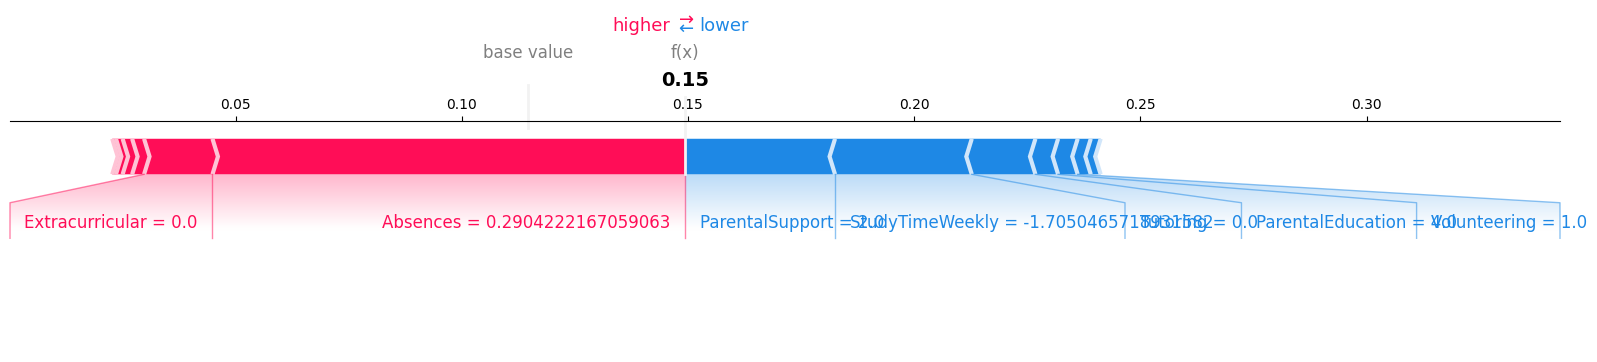

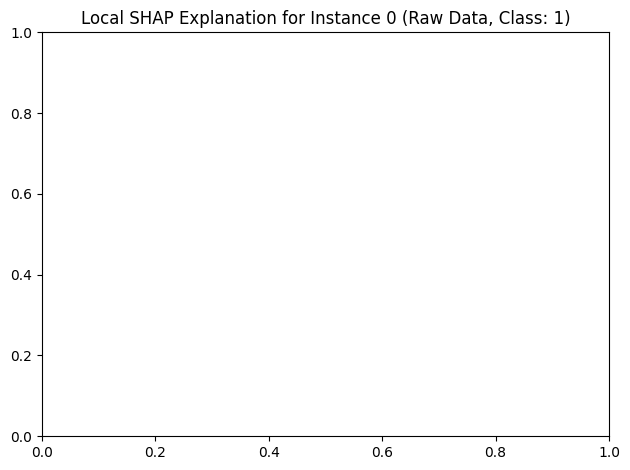

<Figure size 1000x600 with 0 Axes>

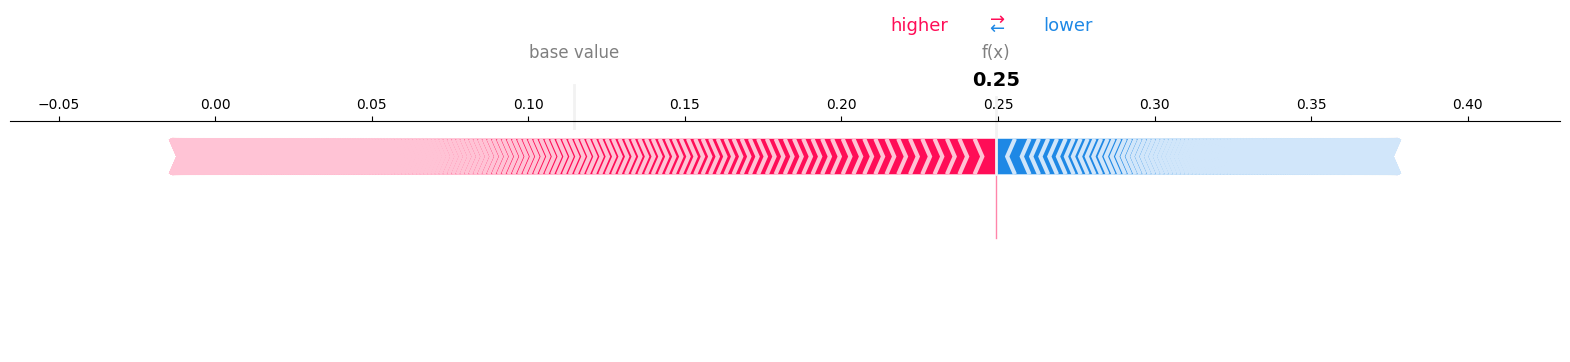

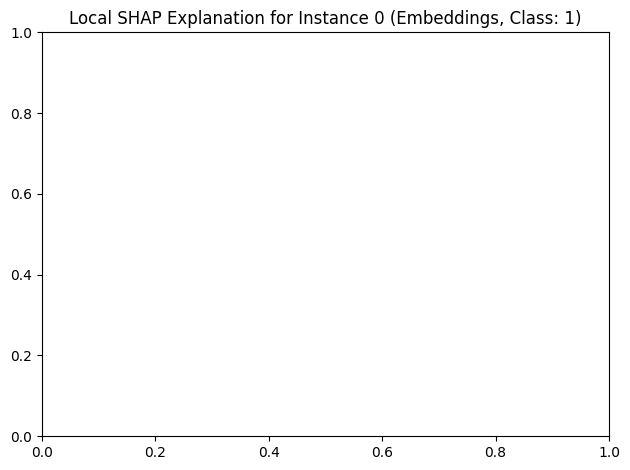

In [ ]:
# --- SHAP Analysis for Local Instance ---
print("\nComputing SHAP Local Feature Importance for Instance...")

# SHAP for Raw Data
explainer_raw = shap.TreeExplainer(rf_clf_raw)
shap_values_raw = explainer_raw.shap_values(X_test_raw)

# SHAP for Embeddings
explainer_emb = shap.TreeExplainer(rf_clf_emb)
shap_values_emb = explainer_emb.shap_values(X_test_emb)

# Local SHAP explanation for a single instance (e.g., instance_idx = 0)
instance_idx = 0

# Debug: Inspect SHAP values structure
print("Debug Info for Raw Data:")
print(f"X_test_raw shape: {X_test_raw.shape}")
print(f"Type of shap_values_raw: {type(shap_values_raw)}")
print(f"Length of shap_values_raw (n_classes): {len(shap_values_raw)}")
for i, class_shap in enumerate(shap_values_raw):
    print(f"shap_values_raw[{i}] shape: {class_shap.shape}")
print(f"X_test_raw[{instance_idx}] shape: {X_test_raw.iloc[instance_idx].shape}")
print(f"shap_values_raw[1][{instance_idx}] shape: {shap_values_raw[1][instance_idx].shape}")
print(f"Number of feature names (X.columns): {len(X.columns)}")

print("\nDebug Info for Embeddings:")
print(f"X_test_emb shape: {X_test_emb.shape}")
print(f"Type of shap_values_emb: {type(shap_values_emb)}")
print(f"Length of shap_values_emb (n_classes): {len(shap_values_emb)}")
for i, class_shap in enumerate(shap_values_emb):
    print(f"shap_values_emb[{i}] shape: {class_shap.shape}")
print(f"X_test_emb[{instance_idx}] shape: {X_test_emb[instance_idx].shape}")
print(f"shap_values_emb[1][{instance_idx}] shape: {shap_values_emb[1][instance_idx].shape}")
print(f"Number of embedding feature names: {len([f'Embedding_{i}' for i in range(X_test_emb.shape[1])])}")

# Verify dimension consistency
if shap_values_raw[1][instance_idx].shape[0] != X_test_raw.iloc[instance_idx].shape[0]:
    print("Warning: Dimension mismatch detected for raw data. Attempting to fix SHAP values...")
    if shap_values_raw[1].shape == (X_test_raw.shape[1], len(class_names)):
        print("SHAP values appear transposed. Transposing back...")
        shap_values_raw = [np.transpose(shap_values_raw[i], (1, 0)) for i in range(len(shap_values_raw))]
        print(f"New shap_values_raw[1] shape: {shap_values_raw[1].shape}")

if shap_values_emb[1][instance_idx].shape[0] != X_test_emb[instance_idx].shape[0]:
    print("Warning: Dimension mismatch detected for embeddings. Attempting to fix SHAP values...")
    if shap_values_emb[1].shape == (X_test_emb.shape[1], len(class_names)):
        print("SHAP values appear transposed. Transposing back...")
        shap_values_emb = [np.transpose(shap_values_emb[i], (1, 0)) for i in range(len(shap_values_emb))]
        print(f"New shap_values_emb[1] shape: {shap_values_emb[1].shape}")

# Re-verify dimension consistency after potential fix
if X_test_raw.iloc[instance_idx].shape[0] != shap_values_raw[1][instance_idx].shape[0]:
    raise ValueError(f"Dimension mismatch for raw data: features ({X_test_raw.iloc[instance_idx].shape[0]}) != SHAP values ({shap_values_raw[1][instance_idx].shape[0]})")
if len(X.columns) != X_test_raw.iloc[instance_idx].shape[0]:
    raise ValueError(f"Feature names length ({len(X.columns)}) != feature values length ({X_test_raw.iloc[instance_idx].shape[0]})")

if X_test_emb[instance_idx].shape[0] != shap_values_emb[1][instance_idx].shape[0]:
    raise ValueError(f"Dimension mismatch for embeddings: features ({X_test_emb[instance_idx].shape[0]}) != SHAP values ({shap_values_emb[1][instance_idx].shape[0]})")
if len([f'Embedding_{i}' for i in range(X_test_emb.shape[1])]) != X_test_emb[instance_idx].shape[0]:
    raise ValueError(f"Embedding feature names length ({len([f'Embedding_{i}' for i in range(X_test_emb.shape[1])])}) != feature values length ({X_test_emb[instance_idx].shape[0]})")

# For raw data
plt.figure(figsize=(10, 6))
shap.force_plot(
    explainer_raw.expected_value[1],  # Base value for class 1
    shap_values_raw[1][instance_idx],  # SHAP values for class 1, instance 0
    X_test_raw.iloc[instance_idx],  # Feature values for instance 0
    feature_names=X.columns,  # Correct feature names from DataFrame
    matplotlib=True  # Static plot for Colab
)
plt.title(f"Local SHAP Explanation for Instance {instance_idx} (Raw Data, Class: {class_names[1]})")
plt.tight_layout()
plt.show()

# For embeddings
plt.figure(figsize=(10, 6))
shap.force_plot(
    explainer_emb.expected_value[1],  # Base value for class 1
    shap_values_emb[1][instance_idx],  # SHAP values for class 1, instance 0
    X_test_emb[instance_idx],  # Feature values for instance 0
    feature_names=[f'Embedding_{i}' for i in range(X_test_emb.shape[1])],  # Embedding feature names
    matplotlib=True  # Static plot for Colab
)
plt.title(f"Local SHAP Explanation for Instance {instance_idx} (Embeddings, Class: {class_names[1]})")
plt.tight_layout()
plt.show()


Computing LIME Local Feature Importance for Instance...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


<Figure size 1000x600 with 0 Axes>

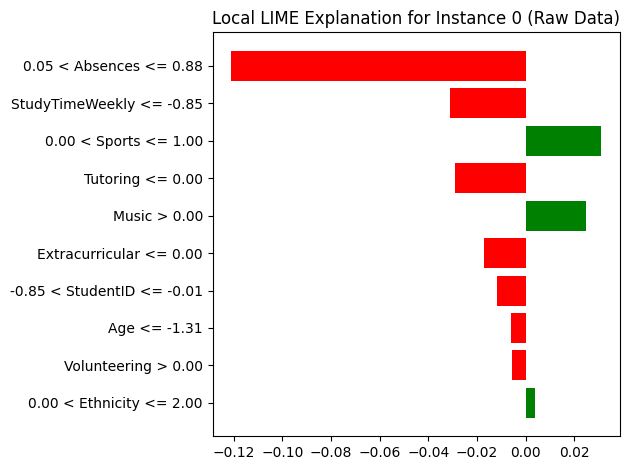

<Figure size 1000x600 with 0 Axes>

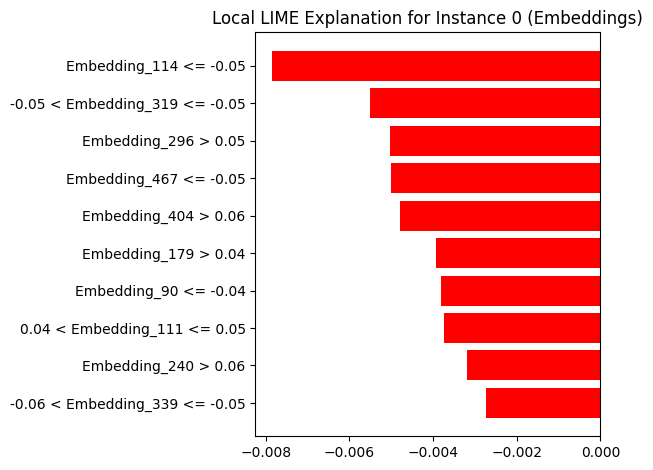


Local SHAP and LIME analysis for instance completed.


In [ ]:
# --- LIME Analysis for Local Instance ---
print("\nComputing LIME Local Feature Importance for Instance...")

# Convert class_names to strings for LIME
lime_class_names = [str(cls) for cls in class_names]

# LIME for Raw Data
lime_explainer_raw = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_raw.values,  # Convert to NumPy array
    feature_names=X.columns,  # Use DataFrame column names
    class_names=lime_class_names,  # Use string-converted class names
    mode='classification'
)

# LIME for Embeddings
lime_explainer_emb = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_emb,  # Already a NumPy array
    feature_names=[f'Embedding_{i}' for i in range(X_train_emb.shape[1])],
    class_names=lime_class_names,  # Use string-converted class names
    mode='classification'
)

# Local LIME explanation for the same instance (instance_idx = 0)
# For raw data
exp_raw = lime_explainer_raw.explain_instance(
    X_test_raw.iloc[instance_idx].values,  # Convert to NumPy array
    rf_clf_raw.predict_proba,
    num_features=10
)
plt.figure(figsize=(10, 6))
exp_raw.as_pyplot_figure()
plt.title(f"Local LIME Explanation for Instance {instance_idx} (Raw Data)")
plt.tight_layout()
plt.show()

# For embeddings
exp_emb = lime_explainer_emb.explain_instance(
    X_test_emb[instance_idx],  # Already a NumPy array
    rf_clf_emb.predict_proba,
    num_features=10
)
plt.figure(figsize=(10, 6))
exp_emb.as_pyplot_figure()
plt.title(f"Local LIME Explanation for Instance {instance_idx} (Embeddings)")
plt.tight_layout()
plt.show()

print("\nLocal SHAP and LIME analysis for instance completed.")


Aggregating and Sorting Combined SHAP and LIME Feature Importance for Instance...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


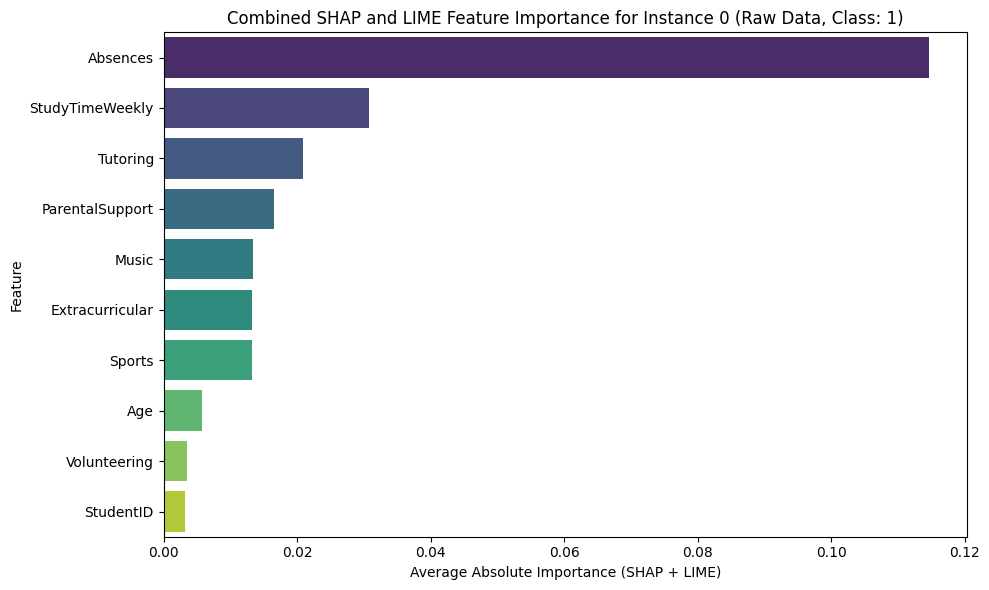

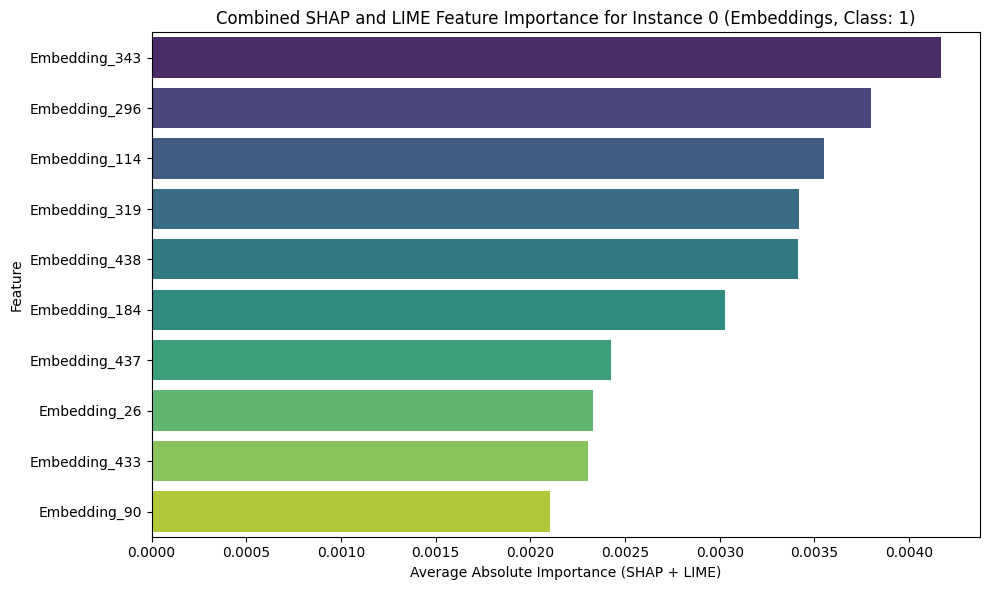


Top 10 Combined Feature Importance for Raw Data:
        Feature  Combined_Importance
       Absences             0.114660
StudyTimeWeekly             0.030826
       Tutoring             0.020930
ParentalSupport             0.016583
          Music             0.013314
Extracurricular             0.013260
         Sports             0.013185
            Age             0.005710
   Volunteering             0.003546
      StudentID             0.003198

Top 10 Combined Feature Importance for Embeddings:
      Feature  Combined_Importance
Embedding_343             0.004166
Embedding_296             0.003800
Embedding_114             0.003551
Embedding_319             0.003418
Embedding_438             0.003413
Embedding_184             0.003028
Embedding_437             0.002426
 Embedding_26             0.002331
Embedding_433             0.002302
 Embedding_90             0.002103

Combined SHAP and LIME feature importance aggregation and sorting completed.


In [ ]:
# --- Aggregation and Sorting of Combined SHAP and LIME Feature Importance ---
print("\nAggregating and Sorting Combined SHAP and LIME Feature Importance for Instance...")

# Local instance index
instance_idx = 0

# Fix SHAP values if transposed
if shap_values_raw[1].shape == (X_test_raw.shape[1], len(class_names)):
    print("Warning: SHAP values for raw data appear transposed. Transposing back...")
    shap_values_raw = [np.transpose(shap_values_raw[i], (1, 0)) for i in range(len(shap_values_raw))]
    print(f"New shap_values_raw[1] shape: {shap_values_raw[1].shape}")

if shap_values_emb[1].shape == (X_test_emb.shape[1], len(class_names)):
    print("Warning: SHAP values for embeddings appear transposed. Transposing back...")
    shap_values_emb = [np.transpose(shap_values_emb[i], (1, 0)) for i in range(len(shap_values_emb))]
    print(f"New shap_values_emb[1] shape: {shap_values_emb[1].shape}")

# Verify dimension consistency
if X_test_raw.iloc[instance_idx].shape[0] != shap_values_raw[1][instance_idx].shape[0]:
    raise ValueError(f"Dimension mismatch for raw data: features ({X_test_raw.iloc[instance_idx].shape[0]}) != SHAP values ({shap_values_raw[1][instance_idx].shape[0]})")
if len(X.columns) != X_test_raw.iloc[instance_idx].shape[0]:
    raise ValueError(f"Feature names length ({len(X.columns)}) != feature values length ({X_test_raw.iloc[instance_idx].shape[0]})")

if X_test_emb[instance_idx].shape[0] != shap_values_emb[1][instance_idx].shape[0]:
    raise ValueError(f"Dimension mismatch for embeddings: features ({X_test_emb[instance_idx].shape[0]}) != SHAP values ({shap_values_emb[1][instance_idx].shape[0]})")
if len([f'Embedding_{i}' for i in range(X_test_emb.shape[1])]) != X_test_emb[instance_idx].shape[0]:
    raise ValueError(f"Embedding feature names length ({len([f'Embedding_{i}' for i in range(X_test_emb.shape[1])])}) != feature values length ({X_test_emb[instance_idx].shape[0]})")

# --- Compute LIME Explanations ---
# LIME for Raw Data
lime_explainer_raw = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_raw.values,  # Convert to NumPy array
    feature_names=X.columns,  # Use DataFrame column names
    class_names=lime_class_names,  # Use string-converted class names
    mode='classification'
)

# LIME for Embeddings
embedding_feature_names = [f'Embedding_{i}' for i in range(X_test_emb.shape[1])]
lime_explainer_emb = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_emb,  # Already a NumPy array
    feature_names=embedding_feature_names,
    class_names=lime_class_names,  # Use string-converted class names
    mode='classification'
)

# Compute LIME explanations for the instance
exp_raw = lime_explainer_raw.explain_instance(
    X_test_raw.iloc[instance_idx].values,  # Convert to NumPy array
    rf_clf_raw.predict_proba,
    num_features=10
)
exp_emb = lime_explainer_emb.explain_instance(
    X_test_emb[instance_idx],  # Already a NumPy array
    rf_clf_emb.predict_proba,
    num_features=10
)

# --- Aggregate SHAP and LIME Importance ---
# For raw data
# SHAP importance
shap_importance_raw = pd.DataFrame({
    'Feature': X.columns,
    'SHAP_Importance': np.abs(shap_values_raw[1][instance_idx])  # Absolute SHAP values for class 1
})

# LIME importance (initialize with zeros for all features)
lime_importance_raw_dict = {feat: 0.0 for feat in X.columns}
for feat_idx, weight in exp_raw.local_exp[1]:  # Use local_exp for class 1
    lime_importance_raw_dict[X.columns[feat_idx]] = abs(weight)  # Absolute LIME weights
lime_importance_raw = pd.DataFrame({
    'Feature': X.columns,
    'LIME_Importance': [lime_importance_raw_dict[feat] for feat in X.columns]
})

# Combine SHAP and LIME
combined_importance_raw = shap_importance_raw.merge(lime_importance_raw, on='Feature')
combined_importance_raw['Combined_Importance'] = (
    combined_importance_raw['SHAP_Importance'] + combined_importance_raw['LIME_Importance']
) / 2  # Average the importance scores
combined_importance_raw = combined_importance_raw.sort_values('Combined_Importance', ascending=False)

# For embeddings
# SHAP importance
shap_importance_emb = pd.DataFrame({
    'Feature': embedding_feature_names,
    'SHAP_Importance': np.abs(shap_values_emb[1][instance_idx])  # Absolute SHAP values for class 1
})

# LIME importance (initialize with zeros for all features)
lime_importance_emb_dict = {feat: 0.0 for feat in embedding_feature_names}
for feat_idx, weight in exp_emb.local_exp[1]:  # Use local_exp for class 1
    lime_importance_emb_dict[embedding_feature_names[feat_idx]] = abs(weight)  # Absolute LIME weights
lime_importance_emb = pd.DataFrame({
    'Feature': embedding_feature_names,
    'LIME_Importance': [lime_importance_emb_dict[feat] for feat in embedding_feature_names]
})

# Combine SHAP and LIME
combined_importance_emb = shap_importance_emb.merge(lime_importance_emb, on='Feature')
combined_importance_emb['Combined_Importance'] = (
    combined_importance_emb['SHAP_Importance'] + combined_importance_emb['LIME_Importance']
) / 2  # Average the importance scores
combined_importance_emb = combined_importance_emb.sort_values('Combined_Importance', ascending=False)

# --- Visualize Combined Feature Importance ---
# For raw data
plt.figure(figsize=(10, 6))
sns.barplot(x='Combined_Importance', y='Feature', data=combined_importance_raw.head(10), hue='Feature', palette='viridis')
plt.title(f"Combined SHAP and LIME Feature Importance for Instance {instance_idx} (Raw Data, Class: {class_names[1]})")
plt.xlabel("Average Absolute Importance (SHAP + LIME)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# For embeddings
plt.figure(figsize=(10, 6))
sns.barplot(x='Combined_Importance', y='Feature', data=combined_importance_emb.head(10), hue='Feature', palette='viridis')
plt.title(f"Combined SHAP and LIME Feature Importance for Instance {instance_idx} (Embeddings, Class: {class_names[1]})")
plt.xlabel("Average Absolute Importance (SHAP + LIME)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# --- Print Sorted Feature Importance ---
print("\nTop 10 Combined Feature Importance for Raw Data:")
print(combined_importance_raw[['Feature', 'Combined_Importance']].head(10).to_string(index=False))

print("\nTop 10 Combined Feature Importance for Embeddings:")
print(combined_importance_emb[['Feature', 'Combined_Importance']].head(10).to_string(index=False))

print("\nCombined SHAP and LIME feature importance aggregation and sorting completed.")


Performing Methodical Ablation...
Ablating features for Raw Data...
Baseline F1-Score (Raw Data, 0% ablated): 0.6857
F1-Score (Raw Data, 10% ablated): 0.3573
F1-Score (Raw Data, 20% ablated): 0.3541
F1-Score (Raw Data, 30% ablated): 0.3711
F1-Score (Raw Data, 40% ablated): 0.3564
F1-Score (Raw Data, 50% ablated): 0.3613
F1-Score (Raw Data, 60% ablated): 0.3363
F1-Score (Raw Data, 70% ablated): 0.3478
F1-Score (Raw Data, 80% ablated): 0.3276
F1-Score (Raw Data, 90% ablated): 0.3276

Ablating features for Embeddings...
Baseline F1-Score (Embeddings, 0% ablated): 0.9521
F1-Score (Embeddings, 10% ablated): 0.9529
F1-Score (Embeddings, 20% ablated): 0.9501
F1-Score (Embeddings, 30% ablated): 0.9529
F1-Score (Embeddings, 40% ablated): 0.9485
F1-Score (Embeddings, 50% ablated): 0.9501
F1-Score (Embeddings, 60% ablated): 0.9492
F1-Score (Embeddings, 70% ablated): 0.9522
F1-Score (Embeddings, 80% ablated): 0.9521
F1-Score (Embeddings, 90% ablated): 0.9521


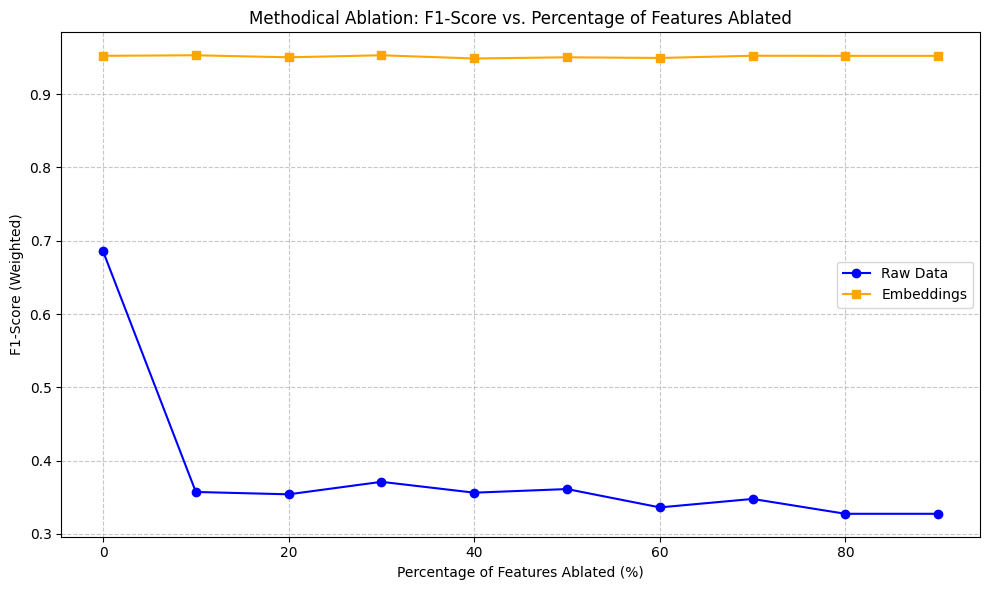


Methodical Ablation completed.


In [ ]:
# --- Methodical Ablation ---
print("\nPerforming Methodical Ablation...")

# Define ablation percentages
ablation_percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Initialize lists to store F1-scores
f1_scores_raw = []
f1_scores_emb = []

# --- Ablation for Raw Data ---
print("Ablating features for Raw Data...")
# Get sorted feature indices based on combined importance
feature_ranking_raw = combined_importance_raw['Feature'].tolist()
num_features_raw = len(feature_ranking_raw)

# Convert to NumPy arrays for ablation
X_train_raw_ablate = X_train_raw.values.copy()
X_test_raw_ablate = X_test_raw.values.copy()

# Baseline model (no ablation)
rf_clf_raw_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_raw_baseline.fit(X_train_raw_ablate, y_train_raw)
y_pred_raw_baseline = rf_clf_raw_baseline.predict(X_test_raw_ablate)
f1_raw_baseline = f1_score(y_test_raw, y_pred_raw_baseline, average='weighted')
f1_scores_raw.append(f1_raw_baseline)
print(f"Baseline F1-Score (Raw Data, 0% ablated): {f1_raw_baseline:.4f}")

# Perform ablation for each percentage
for perc in ablation_percentages:
    num_features_to_ablate = int(num_features_raw * perc)
    features_to_ablate = feature_ranking_raw[:num_features_to_ablate]

    # Set selected features to zero in training and test data
    feature_indices = [X.columns.get_loc(feat) for feat in features_to_ablate]
    X_train_raw_ablate[:, feature_indices] = 0
    X_test_raw_ablate[:, feature_indices] = 0

    # Retrain model
    rf_clf_raw = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_clf_raw.fit(X_train_raw_ablate, y_train_raw)

    # Evaluate F1-score
    y_pred_raw = rf_clf_raw.predict(X_test_raw_ablate)
    f1_raw = f1_score(y_test_raw, y_pred_raw, average='weighted')
    f1_scores_raw.append(f1_raw)
    print(f"F1-Score (Raw Data, {int(perc*100)}% ablated): {f1_raw:.4f}")

# --- Ablation for Embeddings ---
print("\nAblating features for Embeddings...")
# Get sorted feature indices based on combined importance
embedding_feature_names = [f'Embedding_{i}' for i in range(X_test_emb.shape[1])]
feature_ranking_emb = combined_importance_emb['Feature'].tolist()
num_features_emb = len(feature_ranking_emb)

# Copy original training and test data
X_train_emb_ablate = X_train_emb.copy()
X_test_emb_ablate = X_test_emb.copy()

# Baseline model (no ablation)
rf_clf_emb_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_emb_baseline.fit(X_train_emb_ablate, y_train_emb)
y_pred_emb_baseline = rf_clf_emb_baseline.predict(X_test_emb_ablate)
f1_emb_baseline = f1_score(y_test_emb, y_pred_emb_baseline, average='weighted')
f1_scores_emb.append(f1_emb_baseline)
print(f"Baseline F1-Score (Embeddings, 0% ablated): {f1_emb_baseline:.4f}")

# Perform ablation for each percentage
for perc in ablation_percentages:
    num_features_to_ablate = int(num_features_emb * perc)
    features_to_ablate = feature_ranking_emb[:num_features_to_ablate]

    # Set selected features to zero in training and test data
    feature_indices = [embedding_feature_names.index(feat) for feat in features_to_ablate]
    X_train_emb_ablate[:, feature_indices] = 0
    X_test_emb_ablate[:, feature_indices] = 0

    # Retrain model
    rf_clf_emb = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_clf_emb.fit(X_train_emb_ablate, y_train_emb)

    # Evaluate F1-score
    y_pred_emb = rf_clf_emb.predict(X_test_emb_ablate)
    f1_emb = f1_score(y_test_emb, y_pred_emb, average='weighted')
    f1_scores_emb.append(f1_emb)
    print(f"F1-Score (Embeddings, {int(perc*100)}% ablated): {f1_emb:.4f}")

# --- Visualize Methodical Ablation Curve ---
# Plot F1-scores vs. ablation percentages
plt.figure(figsize=(10, 6))
percentages = [0] + ablation_percentages  # Include 0% for baseline
plt.plot([p * 100 for p in percentages], f1_scores_raw, marker='o', label='Raw Data', color='blue')
plt.plot([p * 100 for p in percentages], f1_scores_emb, marker='s', label='Embeddings', color='orange')
plt.title("Methodical Ablation: F1-Score vs. Percentage of Features Ablated")
plt.xlabel("Percentage of Features Ablated (%)")
plt.ylabel("F1-Score (Weighted)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print("\nMethodical Ablation completed.")


Performing Random Ablation...
Randomly ablating features for Raw Data...
Baseline F1-Score (Raw Data, 0% ablated): 0.6857
Average F1-Score (Raw Data, 10% ablated, 25 iterations): 0.6371
Average F1-Score (Raw Data, 20% ablated, 25 iterations): 0.6257
Average F1-Score (Raw Data, 30% ablated, 25 iterations): 0.5748
Average F1-Score (Raw Data, 40% ablated, 25 iterations): 0.5387
Average F1-Score (Raw Data, 50% ablated, 25 iterations): 0.5161
Average F1-Score (Raw Data, 60% ablated, 25 iterations): 0.4643
Average F1-Score (Raw Data, 70% ablated, 25 iterations): 0.4310
Average F1-Score (Raw Data, 80% ablated, 25 iterations): 0.4064
Average F1-Score (Raw Data, 90% ablated, 25 iterations): 0.3815

Randomly ablating features for Embeddings...
Baseline F1-Score (Embeddings, 0% ablated): 0.9521
Average F1-Score (Embeddings, 10% ablated, 25 iterations): 0.9513
Average F1-Score (Embeddings, 20% ablated, 25 iterations): 0.9517
Average F1-Score (Embeddings, 30% ablated, 25 iterations): 0.9501
Averag

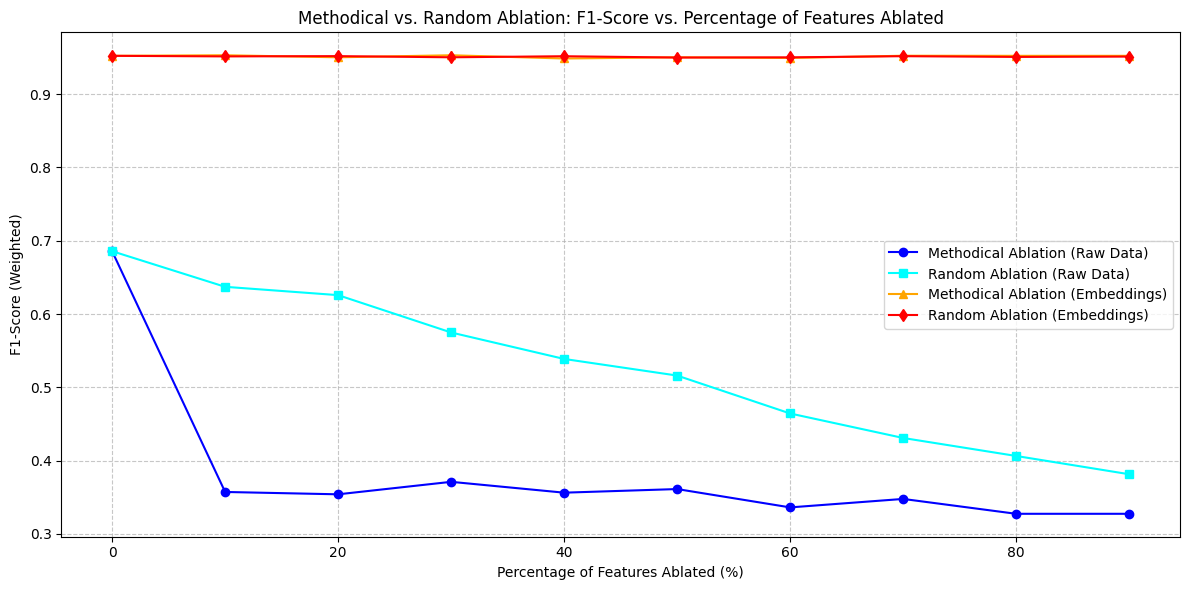


Random Ablation completed.


In [ ]:
# --- Random Ablation ---
print("\nPerforming Random Ablation...")

# Define ablation percentages and number of iterations
ablation_percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
num_iterations = 25

# Initialize lists to store average F1-scores
f1_scores_random_raw = []
f1_scores_random_emb = []

# --- Random Ablation for Raw Data ---
print("Randomly ablating features for Raw Data...")
num_features_raw = X_train_raw.shape[1]

# Baseline F1-score (already computed in methodical ablation)
f1_scores_random_raw.append(f1_scores_raw[0])  # Use methodical ablation baseline
print(f"Baseline F1-Score (Raw Data, 0% ablated): {f1_scores_raw[0]:.4f}")

# Perform random ablation for each percentage
for perc in ablation_percentages:
    f1_scores_iter = []
    num_features_to_ablate = int(num_features_raw * perc)

    for _ in range(num_iterations):
        # Randomly select features to ablate
        feature_indices = np.random.choice(num_features_raw, size=num_features_to_ablate, replace=False)

        # Copy original data as NumPy arrays
        X_train_raw_ablate = X_train_raw.values.copy()
        X_test_raw_ablate = X_test_raw.values.copy()

        # Set selected features to zero
        X_train_raw_ablate[:, feature_indices] = 0
        X_test_raw_ablate[:, feature_indices] = 0

        # Retrain model
        rf_clf_raw = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_clf_raw.fit(X_train_raw_ablate, y_train_raw)

        # Evaluate F1-score
        y_pred_raw = rf_clf_raw.predict(X_test_raw_ablate)
        f1_raw = f1_score(y_test_raw, y_pred_raw, average='weighted')
        f1_scores_iter.append(f1_raw)

    # Compute average F1-score across iterations
    avg_f1_raw = np.mean(f1_scores_iter)
    f1_scores_random_raw.append(avg_f1_raw)
    print(f"Average F1-Score (Raw Data, {int(perc*100)}% ablated, {num_iterations} iterations): {avg_f1_raw:.4f}")

# --- Random Ablation for Embeddings ---
print("\nRandomly ablating features for Embeddings...")
num_features_emb = X_train_emb.shape[1]

# Baseline F1-score (already computed in methodical ablation)
f1_scores_random_emb.append(f1_scores_emb[0])  # Use methodical ablation baseline
print(f"Baseline F1-Score (Embeddings, 0% ablated): {f1_scores_emb[0]:.4f}")

# Perform random ablation for each percentage
for perc in ablation_percentages:
    f1_scores_iter = []
    num_features_to_ablate = int(num_features_emb * perc)

    for _ in range(num_iterations):
        # Randomly select features to ablate
        feature_indices = np.random.choice(num_features_emb, size=num_features_to_ablate, replace=False)

        # Copy original data
        X_train_emb_ablate = X_train_emb.copy()
        X_test_emb_ablate = X_test_emb.copy()

        # Set selected features to zero
        X_train_emb_ablate[:, feature_indices] = 0
        X_test_emb_ablate[:, feature_indices] = 0

        # Retrain model
        rf_clf_emb = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_clf_emb.fit(X_train_emb_ablate, y_train_emb)

        # Evaluate F1-score
        y_pred_emb = rf_clf_emb.predict(X_test_emb_ablate)
        f1_emb = f1_score(y_test_emb, y_pred_emb, average='weighted')
        f1_scores_iter.append(f1_emb)

    # Compute average F1-score across iterations
    avg_f1_emb = np.mean(f1_scores_iter)
    f1_scores_random_emb.append(avg_f1_emb)
    print(f"Average F1-Score (Embeddings, {int(perc*100)}% ablated, {num_iterations} iterations): {avg_f1_emb:.4f}")

# --- Visualize Methodical vs. Random Ablation ---
# Plot F1-scores vs. ablation percentages
percentages = [0] + ablation_percentages  # Include 0% for baseline
plt.figure(figsize=(12, 6))

# Raw Data
plt.plot([p * 100 for p in percentages], f1_scores_raw, marker='o', label='Methodical Ablation (Raw Data)', color='blue')
plt.plot([p * 100 for p in percentages], f1_scores_random_raw, marker='s', label='Random Ablation (Raw Data)', color='cyan')

# Embeddings
plt.plot([p * 100 for p in percentages], f1_scores_emb, marker='^', label='Methodical Ablation (Embeddings)', color='orange')
plt.plot([p * 100 for p in percentages], f1_scores_random_emb, marker='d', label='Random Ablation (Embeddings)', color='red')

plt.title("Methodical vs. Random Ablation: F1-Score vs. Percentage of Features Ablated")
plt.xlabel("Percentage of Features Ablated (%)")
plt.ylabel("F1-Score (Weighted)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print("\nRandom Ablation completed.")


Calculating diffAUC for Ablation Curves...
diffAUC (Raw Data): 14.0926
diffAUC (Embeddings): -0.0177
Interpretation (Raw Data): The model is more sensitive to the removal of XAI-ranked features (methodical ablation causes a greater F1-score drop than random ablation), validating the importance ranking.
Interpretation (Embeddings): The model shows similar sensitivity to both methodical and random ablation, suggesting the XAI ranking may not strongly differentiate important features.


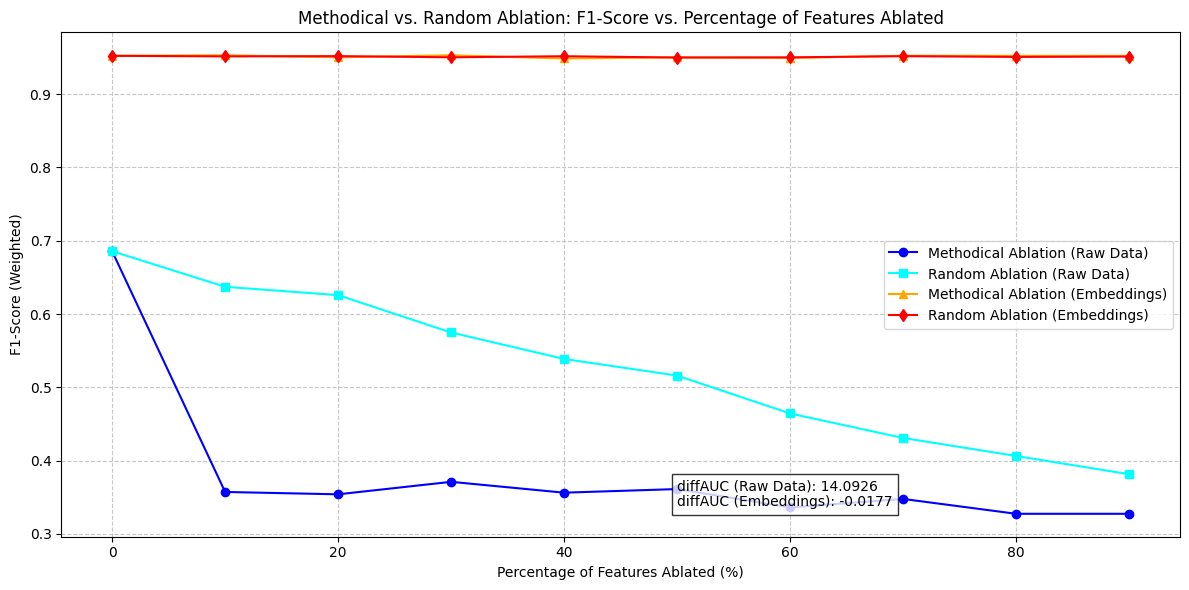


diffAUC calculation and visualization completed.


In [ ]:
# --- Calculate diffAUC ---
print("\nCalculating diffAUC for Ablation Curves...")

# Compute AUC for methodical and random ablation curves
percentages = [0] + ablation_percentages  # Include 0% for baseline
x_percentages = [p * 100 for p in percentages]  # Convert to percentages for AUC

# Compute AUC using trapezoidal rule
auc_methodical_raw = auc(x_percentages, f1_scores_raw)
auc_random_raw = auc(x_percentages, f1_scores_random_raw)
auc_methodical_emb = auc(x_percentages, f1_scores_emb)
auc_random_emb = auc(x_percentages, f1_scores_random_emb)

# Compute diffAUC (Random - Methodical)
diff_auc_raw = auc_random_raw - auc_methodical_raw
diff_auc_emb = auc_random_emb - auc_methodical_emb

# Print diffAUC values
print(f"diffAUC (Raw Data): {diff_auc_raw:.4f}")
print(f"diffAUC (Embeddings): {diff_auc_emb:.4f}")

# Interpretation
if diff_auc_raw > 0:
    print("Interpretation (Raw Data): The model is more sensitive to the removal of XAI-ranked features (methodical ablation causes a greater F1-score drop than random ablation), validating the importance ranking.")
else:
    print("Interpretation (Raw Data): The model shows similar sensitivity to both methodical and random ablation, suggesting the XAI ranking may not strongly differentiate important features.")

if diff_auc_emb > 0:
    print("Interpretation (Embeddings): The model is more sensitive to the removal of XAI-ranked features (methodical ablation causes a greater F1-score drop than random ablation), validating the importance ranking.")
else:
    print("Interpretation (Embeddings): The model shows similar sensitivity to both methodical and random ablation, suggesting the XAI ranking may not strongly differentiate important features.")

# --- Visualize Ablation Curves with diffAUC ---
plt.figure(figsize=(12, 6))

# Raw Data
plt.plot(x_percentages, f1_scores_raw, marker='o', label='Methodical Ablation (Raw Data)', color='blue')
plt.plot(x_percentages, f1_scores_random_raw, marker='s', label='Random Ablation (Raw Data)', color='cyan')

# Embeddings
plt.plot(x_percentages, f1_scores_emb, marker='^', label='Methodical Ablation (Embeddings)', color='orange')
plt.plot(x_percentages, f1_scores_random_emb, marker='d', label='Random Ablation (Embeddings)', color='red')

# Annotate diffAUC
plt.text(50, min(f1_scores_raw + f1_scores_random_raw + f1_scores_emb + f1_scores_random_emb) + 0.01,
         f'diffAUC (Raw Data): {diff_auc_raw:.4f}\ndiffAUC (Embeddings): {diff_auc_emb:.4f}',
         bbox=dict(facecolor='white', alpha=0.8))

plt.title("Methodical vs. Random Ablation: F1-Score vs. Percentage of Features Ablated")
plt.xlabel("Percentage of Features Ablated (%)")
plt.ylabel("F1-Score (Weighted)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print("\ndiffAUC calculation and visualization completed.")